# 078: KmerSeek hp_thomas_dill k=26 — Mechanism Analysis

Analyses for the **best HP alphabet/ksize** (`hp_thomas_dill`, k=26, chosen in notebook 075):

1. **Head-to-head ranking**: KmerSeek vs FoldSeek per query, on the shared benchmark set
2. **Selection bias**: are KmerSeek-covered queries structurally biased?
3. **Sequence identity**: at what % identity do KmerSeek's HP k-mer hits fire?
4. **FoldSeek failure mode**: what goes wrong for FoldSeek on KmerSeek-winning queries?
5. **Protein disorder**: are KmerSeek wins in disordered regions?

**Not repeated here** (already in 075): k-size sweep, AUC vs ksize plots, lift figure,
per-class sensitivity curves, TP/FP validation, top-families, unclassified enrichment stats.

In [29]:
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [30]:
import sys, gc
from pathlib import Path
from collections import Counter

import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import mannwhitneyu

sys.path.append(str(Path.cwd()))
from scope_kmerseek_utils import (
    EVAL_USECOLS, TEA_DIR, SCOPE_CLASS_DESCRIPTIONS,
    load_baselines, add_composite_scores_scope,
    recompute_bonferroni, eval_tsv_to_rocx, sensitivity_stats,
)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.dpi'] = 120

SWEEP_DIR       = Path.home() / 'data/scope/results-hp-alphabet-sweep'
SCOPE_DOMAINS_PATH = Path.home() / 'data/scope/results-scope-pvalue-benchmark/scope_domains.tsv'
FASTA_PATH      = Path.home() / 'data/scope/astral-scopedom-seqres-gd-sel-gs-bib-40-2.08.fa'
FIG_PREFIX = '../figures/078'
Path('../figures').mkdir(exist_ok=True)

BEST_LABEL      = 'hp_thomas_dill'
BEST_K          = 26
BONF_THRESHOLD  = 0.05
SCORE_COL       = 'jaccard'
EXCLUDE_GZ      = True

## 1. Load data

In [31]:
foldseek, tea_all = load_baselines(TEA_DIR)
ref_queries = set(foldseek['NAME'].to_list())
scope_domains = pl.read_csv(SCOPE_DOMAINS_PATH, separator='\t')
print(f'FoldSeek queries: {len(ref_queries):,}')

eval_file = next(
    p for p in [
        SWEEP_DIR / f'scope_eval.{BEST_LABEL}.k{BEST_K}.tsv.gz',
        SWEEP_DIR / f'scope_eval.{BEST_LABEL}.k{BEST_K}.tsv',
    ]
    if p.exists()
)
print(f'Loading: {eval_file.name}')
SEQ_COLS  = EVAL_USECOLS + [
    'q_scop_family', 'q_scop_class',
    'query_subseq', 'target_subseq',
    'query_start', 'query_end', 'region_length',
]
ev_full = pl.read_csv(eval_file, separator='\t')
ev_seq  = ev_full.select([c for c in SEQ_COLS if c in ev_full.columns])

ev = add_composite_scores_scope(ev_full.select([c for c in EVAL_USECOLS if c in ev_full.columns]))
ev = recompute_bonferroni(ev)
ev_filt = ev.filter(pl.col('bonferroni_correct') < BONF_THRESHOLD)
print(f'k={BEST_K} after Bonf<{BONF_THRESHOLD}: {len(ev_filt):,} pairs')

# Restore seq cols on filtered rows
ev_filt_seq = ev_filt.join(
    ev_seq.select([c for c in ['query_domain','target_domain','query_subseq',
                   'target_subseq','query_start','query_end','region_length']
                   if c in ev_seq.columns]),
    on=['query_domain','target_domain'], how='left')

km_rocx   = eval_tsv_to_rocx(ev_filt, score_col=SCORE_COL, ascending=False,
                               exclude_gray_zone=EXCLUDE_GZ)
km_rocx_r = km_rocx.filter(pl.col('NAME').is_in(ref_queries))
covered   = set(km_rocx_r['NAME'].to_list())
uncovered = ref_queries - covered

n_km_total = km_rocx['NAME'].n_unique()
print(f'KmerSeek covered (all):            {n_km_total:,}')
print(f'KmerSeek covered in FS benchmark:  {len(covered):,} ({100*len(covered)/len(ref_queries):.1f}% of FS ref)')
print(f'KmerSeek-only (outside benchmark): {n_km_total - len(covered):,}')
del ev, ev_filt; gc.collect()

FoldSeek queries: 5,713
Loading: scope_eval.hp_thomas_dill.k26.tsv.gz
k=26 after Bonf<0.05: 7,330 pairs
KmerSeek covered (all):            683
KmerSeek covered in FS benchmark:  228 (4.0% of FS ref)
KmerSeek-only (outside benchmark): 455


89350

## 2. Head-to-head: KmerSeek vs FoldSeek on covered queries

Both methods evaluated on the same set of queries (those KmerSeek has Bonf-sig hits for).


In [32]:
fs_cov  = foldseek.filter(pl.col('NAME').is_in(covered))
tea_cov = tea_all.filter(pl.col('NAME').is_in(covered))

_, _, km_fam_own  = sensitivity_stats(km_rocx,   'FAM')
_, _, km_sfam_own = sensitivity_stats(km_rocx,   'SFAM')
_, _, km_fam   = sensitivity_stats(km_rocx_r, 'FAM')
_, _, km_sfam  = sensitivity_stats(km_rocx_r, 'SFAM')
_, _, fs_fam   = sensitivity_stats(foldseek,  'FAM')
_, _, fs_sfam  = sensitivity_stats(foldseek,  'SFAM')
_, _, fsc_fam  = sensitivity_stats(fs_cov,    'FAM')
_, _, fsc_sfam = sensitivity_stats(fs_cov,    'SFAM')
_, _, teac_fam = sensitivity_stats(tea_cov,   'FAM')

print(f'{"Method":<55} {"FAM AUC":>9} {"SFAM AUC":>10}  n_queries')
print('-' * 85)
print(f'{"FoldSeek (all 5713)":<55} {fs_fam:>9.4f} {fs_sfam:>10.4f}  {foldseek["NAME"].n_unique():,}')
print(f'{"FoldSeek (KmerSeek-covered subset)":<55} {fsc_fam:>9.4f} {fsc_sfam:>10.4f}  {len(covered):,}')
print(f'{"TEA (KmerSeek-covered subset)":<55} {teac_fam:>9.4f}  {"n/a":>10}  {len(covered):,}')
print(f'{"KmerSeek {BEST_LABEL} k={BEST_K} (OWN full set)".format(BEST_LABEL=BEST_LABEL, BEST_K=BEST_K):<55} {km_fam_own:>9.4f} {km_sfam_own:>10.4f}  {n_km_total:,}')
print(f'{"KmerSeek {BEST_LABEL} k={BEST_K} (matched to FS)".format(BEST_LABEL=BEST_LABEL, BEST_K=BEST_K):<55} {km_fam:>9.4f} {km_sfam:>10.4f}  {len(covered):,}')


Method                                                    FAM AUC   SFAM AUC  n_queries
-------------------------------------------------------------------------------------
FoldSeek (all 5713)                                        0.8169     0.5743  5,713
FoldSeek (KmerSeek-covered subset)                         0.8728     0.7135  228
TEA (KmerSeek-covered subset)                              0.8796         n/a  228
KmerSeek hp_thomas_dill k=26 (OWN full set)                0.8465     0.1392  683
KmerSeek hp_thomas_dill k=26 (matched to FS)               0.8209     0.1601  228


Per-query family sensitivity (covered queries):
  KmerSeek FAM > FoldSeek FAM : 110
  FoldSeek FAM > KmerSeek FAM : 41
  Both detect (FAM>0)         : 188
  KmerSeek only               : 0
  FoldSeek only               : 40


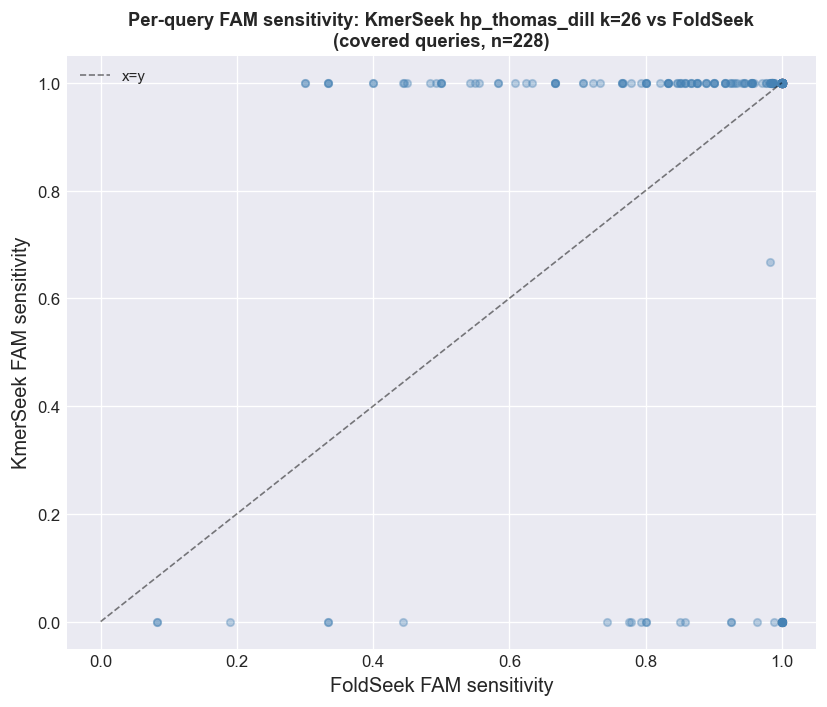

In [33]:
km_per_q = km_rocx_r.select(['NAME','FAM']).rename({'FAM':'km_fam'})
fs_per_q = fs_cov.select(['NAME','FAM']).rename({'FAM':'fs_fam'})
per_q = km_per_q.join(fs_per_q, on='NAME', how='left')

km_beats_fs = per_q.filter(pl.col('km_fam') >  pl.col('fs_fam'))
fs_beats_km = per_q.filter(pl.col('fs_fam') >  pl.col('km_fam'))
both_detect = per_q.filter((pl.col('km_fam') > 0) & (pl.col('fs_fam') > 0))
km_only     = per_q.filter((pl.col('km_fam') > 0) & (pl.col('fs_fam') == 0))
fs_only     = per_q.filter((pl.col('km_fam') == 0) & (pl.col('fs_fam') > 0))

print('Per-query family sensitivity (covered queries):')
print(f'  KmerSeek FAM > FoldSeek FAM : {len(km_beats_fs):,}')
print(f'  FoldSeek FAM > KmerSeek FAM : {len(fs_beats_km):,}')
print(f'  Both detect (FAM>0)         : {len(both_detect):,}')
print(f'  KmerSeek only               : {len(km_only):,}')
print(f'  FoldSeek only               : {len(fs_only):,}')

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(per_q['fs_fam'].to_numpy(), per_q['km_fam'].to_numpy(),
           alpha=0.35, s=20, color='steelblue')
ax.plot([0,1],[0,1],'k--',lw=1,alpha=0.5,label='x=y')
ax.set_xlabel('FoldSeek FAM sensitivity', fontsize=12)
ax.set_ylabel('KmerSeek FAM sensitivity', fontsize=12)
ax.set_title('Per-query FAM sensitivity: KmerSeek {} k={} vs FoldSeek'.format(BEST_LABEL, BEST_K)
             + '\n(covered queries, n={:,})'.format(len(covered)),
             fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('{}_per_query_scatter.png'.format(FIG_PREFIX), dpi=150, bbox_inches='tight')
plt.show()


## 3. Selection bias: covered vs uncovered query characterisation

Are KmerSeek-covered queries drawn from specific SCOP classes, or do they have unusually large families?


Family peers — covered: median=20, uncovered: median=9
Mann-Whitney U (covered > uncovered): p=0.0000


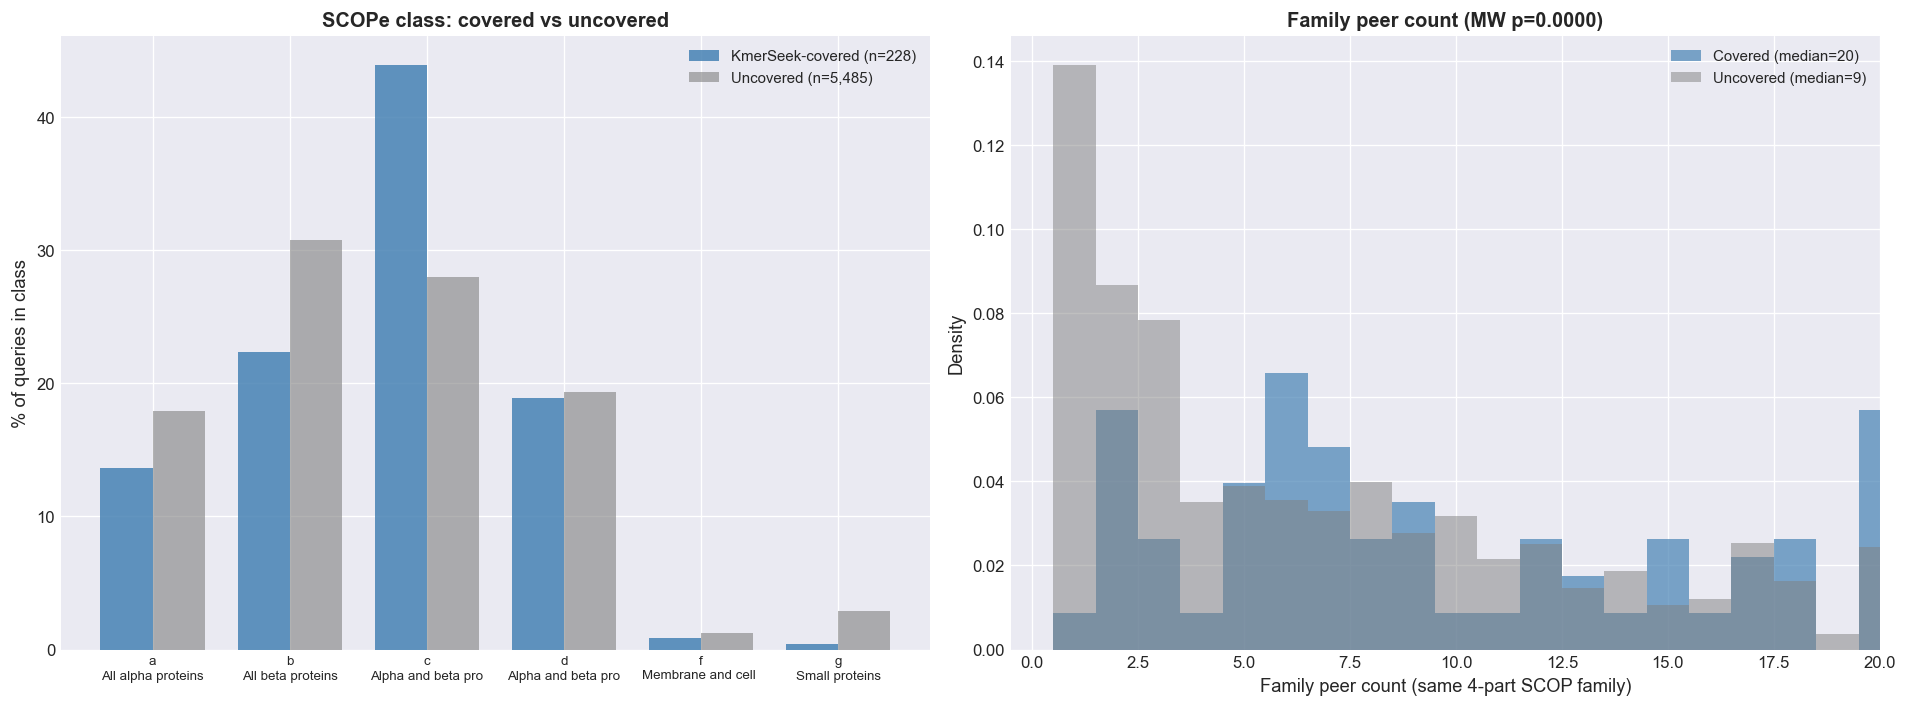

In [34]:
def scop_class_of(query_set, rocx):
    return (rocx.filter(pl.col('NAME').is_in(query_set))
                .select(['NAME','SCOP']).unique()
                .with_columns(pl.col('SCOP').str.slice(0,1).alias('cls')))

cls_covered   = scop_class_of(covered,   foldseek)
cls_uncovered = scop_class_of(uncovered, foldseek)

scop_df = (foldseek.select(['NAME','SCOP']).unique()
           .with_columns(
               pl.col('SCOP').str.split('.').list.slice(0,4).list.join('.').alias('fam4')))
fam_sizes = (scop_df.group_by('fam4')
             .agg(pl.len().alias('n'))
             .with_columns((pl.col('n')-1).alias('fam_peers')))
scop_peers = scop_df.join(fam_sizes, on='fam4', how='left')

peers_cov = scop_peers.filter(pl.col('NAME').is_in(covered))['fam_peers'].to_numpy()
peers_unc = scop_peers.filter(pl.col('NAME').is_in(uncovered))['fam_peers'].to_numpy()

stat, pval = mannwhitneyu(peers_cov, peers_unc, alternative='greater')
print(f'Family peers — covered: median={np.median(peers_cov):.0f}, uncovered: median={np.median(peers_unc):.0f}')
print(f'Mann-Whitney U (covered > uncovered): p={pval:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
ax = axes[0]
all_cls = sorted(set(cls_covered['cls'].to_list()) | set(cls_uncovered['cls'].to_list()))
n_cov, n_unc = len(covered), len(uncovered)
pct_cov = Counter(cls_covered['cls'].to_list())
pct_unc = Counter(cls_uncovered['cls'].to_list())
x = np.arange(len(all_cls)); w = 0.38
ax.bar(x-w/2, [pct_cov.get(c,0)/n_cov*100 for c in all_cls], w,
       color='steelblue', alpha=0.85, label='KmerSeek-covered (n={:,})'.format(n_cov))
ax.bar(x+w/2, [pct_unc.get(c,0)/n_unc*100 for c in all_cls], w,
       color='grey', alpha=0.6, label='Uncovered (n={:,})'.format(n_unc))
ax.set_xticks(x)
ax.set_xticklabels(['{}'.format(c) + '\n' + SCOPE_CLASS_DESCRIPTIONS.get(c,c)[:18] for c in all_cls], fontsize=8)
ax.set_ylabel('% of queries in class', fontsize=11)
ax.set_title('SCOPe class: covered vs uncovered', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)

ax = axes[1]
bins = np.arange(0, max(peers_cov.max(), peers_unc.max())+2)-0.5
ax.hist(peers_cov, bins=bins, density=True, alpha=0.7, color='steelblue',
        label='Covered (median={:.0f})'.format(np.median(peers_cov)))
ax.hist(peers_unc, bins=bins, density=True, alpha=0.5, color='grey',
        label='Uncovered (median={:.0f})'.format(np.median(peers_unc)))
ax.set_xlabel('Family peer count (same 4-part SCOP family)', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title('Family peer count (MW p={:.4f})'.format(pval), fontsize=12, fontweight='bold')
ax.legend(fontsize=9); ax.set_xlim(-0.5, 20)
plt.tight_layout()
plt.savefig('{}_covered_vs_uncovered.png'.format(FIG_PREFIX), dpi=150, bbox_inches='tight')
plt.show()


## 4. Where does KmerSeek beat / lose to FoldSeek per query?

KM>FS: 110  FS>KM: 41  Tied: 77
  a KM>FS= 21 FS>KM=  4 Tied=  6  All alpha proteins
  b KM>FS= 19 FS>KM= 11 Tied= 21  All beta proteins
  c KM>FS= 44 FS>KM= 18 Tied= 38  Alpha and beta proteins (a/b) — alternat
  d KM>FS= 26 FS>KM=  6 Tied= 11  Alpha and beta proteins (a+b) — segregat
  f KM>FS=  0 FS>KM=  2 Tied=  0  Membrane and cell surface proteins
  g KM>FS=  0 FS>KM=  0 Tied=  1  Small proteins


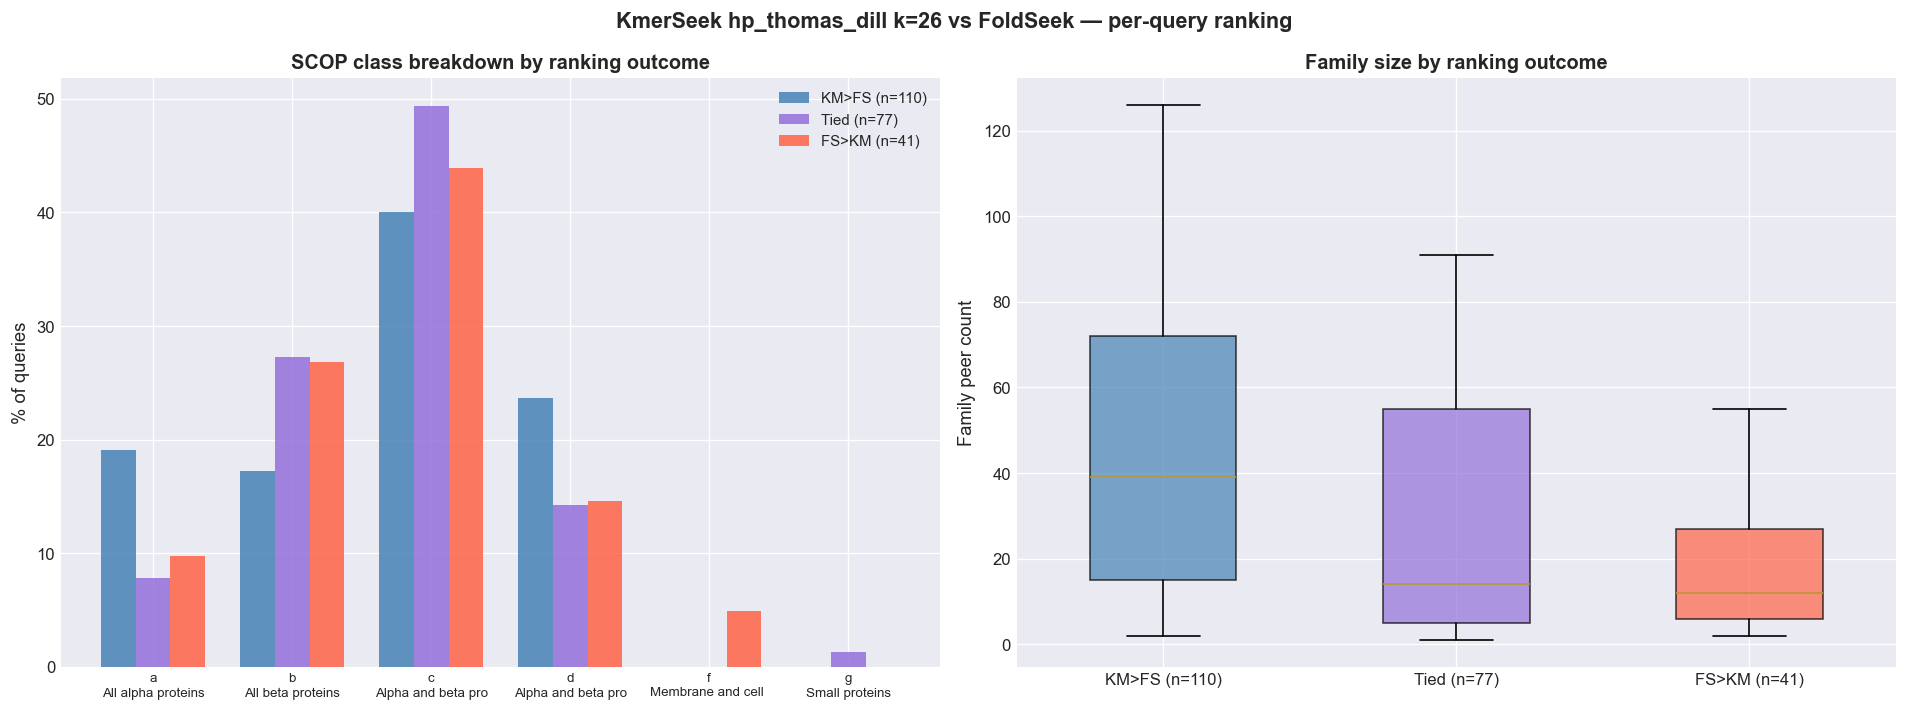

In [35]:
km_beats_names = set(km_beats_fs['NAME'].to_list())
fs_beats_names = set(fs_beats_km['NAME'].to_list())
tied_names     = set(per_q.filter(pl.col('km_fam') == pl.col('fs_fam'))['NAME'].to_list())

cls_km_b = Counter(scop_class_of(km_beats_names, foldseek)['cls'].to_list())
cls_fs_b = Counter(scop_class_of(fs_beats_names, foldseek)['cls'].to_list())
cls_tied = Counter(scop_class_of(tied_names,     foldseek)['cls'].to_list())
all_c = sorted(set(cls_km_b) | set(cls_fs_b) | set(cls_tied))

print(f'KM>FS: {len(km_beats_names):,}  FS>KM: {len(fs_beats_names):,}  Tied: {len(tied_names):,}')
for c in all_c:
    print('  {} KM>FS={:3d} FS>KM={:3d} Tied={:3d}  {}'.format(
        c, cls_km_b.get(c,0), cls_fs_b.get(c,0), cls_tied.get(c,0),
        SCOPE_CLASS_DESCRIPTIONS.get(c,c)[:40]))

def peers_of(qset):
    return scop_peers.filter(pl.col('NAME').is_in(qset))['fam_peers'].to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
ax = axes[0]
groups = [('KM>FS', cls_km_b,'steelblue'), ('Tied', cls_tied,'mediumpurple'), ('FS>KM', cls_fs_b,'tomato')]
x = np.arange(len(all_c)); w = 0.25
for i, (lbl, cnt, color) in enumerate(groups):
    n = sum(cnt.values()) or 1
    ax.bar(x+(i-1)*w, [cnt.get(c,0)/n*100 for c in all_c], w,
           color=color, alpha=0.85, label='{} (n={})'.format(lbl, sum(cnt.values())))
ax.set_xticks(x)
ax.set_xticklabels([c+'\n'+SCOPE_CLASS_DESCRIPTIONS.get(c,c)[:18] for c in all_c], fontsize=8)
ax.set_ylabel('% of queries', fontsize=11)
ax.set_title('SCOP class breakdown by ranking outcome', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)

ax = axes[1]
data_g = [('KM>FS', peers_of(km_beats_names),'steelblue'),
           ('Tied',  peers_of(tied_names),    'mediumpurple'),
           ('FS>KM', peers_of(fs_beats_names),'tomato')]
bp = ax.boxplot([d for _,d,_ in data_g], positions=list(range(len(data_g))),
                patch_artist=True, widths=0.5, showfliers=False)
for patch, (_,_,color) in zip(bp['boxes'], data_g):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax.set_xticks(list(range(len(data_g))))
ax.set_xticklabels(['{} (n={})'.format(l, len(d)) for l,d,_ in data_g], fontsize=10)
ax.set_ylabel('Family peer count', fontsize=11)
ax.set_title('Family size by ranking outcome', fontsize=12, fontweight='bold')
plt.suptitle('KmerSeek {} k={} vs FoldSeek — per-query ranking'.format(BEST_LABEL, BEST_K),
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('{}_km_beats_fs.png'.format(FIG_PREFIX), dpi=150, bbox_inches='tight')
plt.show()


Family peer count tertile cutoffs: 11, 55
Class a (n= 31): KmerSeek=0.855  FoldSeek=0.783  lift=+0.072
Class b (n= 51): KmerSeek=0.775  FoldSeek=0.871  lift=-0.097
Class c (n=100): KmerSeek=0.815  FoldSeek=0.908  lift=-0.093
Class d (n= 43): KmerSeek=0.864  FoldSeek=0.804  lift=+0.060
Class f (n=  2): KmerSeek=0.000  FoldSeek=0.500  lift=-0.500
Class g (n=  1): KmerSeek=0.000  FoldSeek=0.000  lift=+0.000


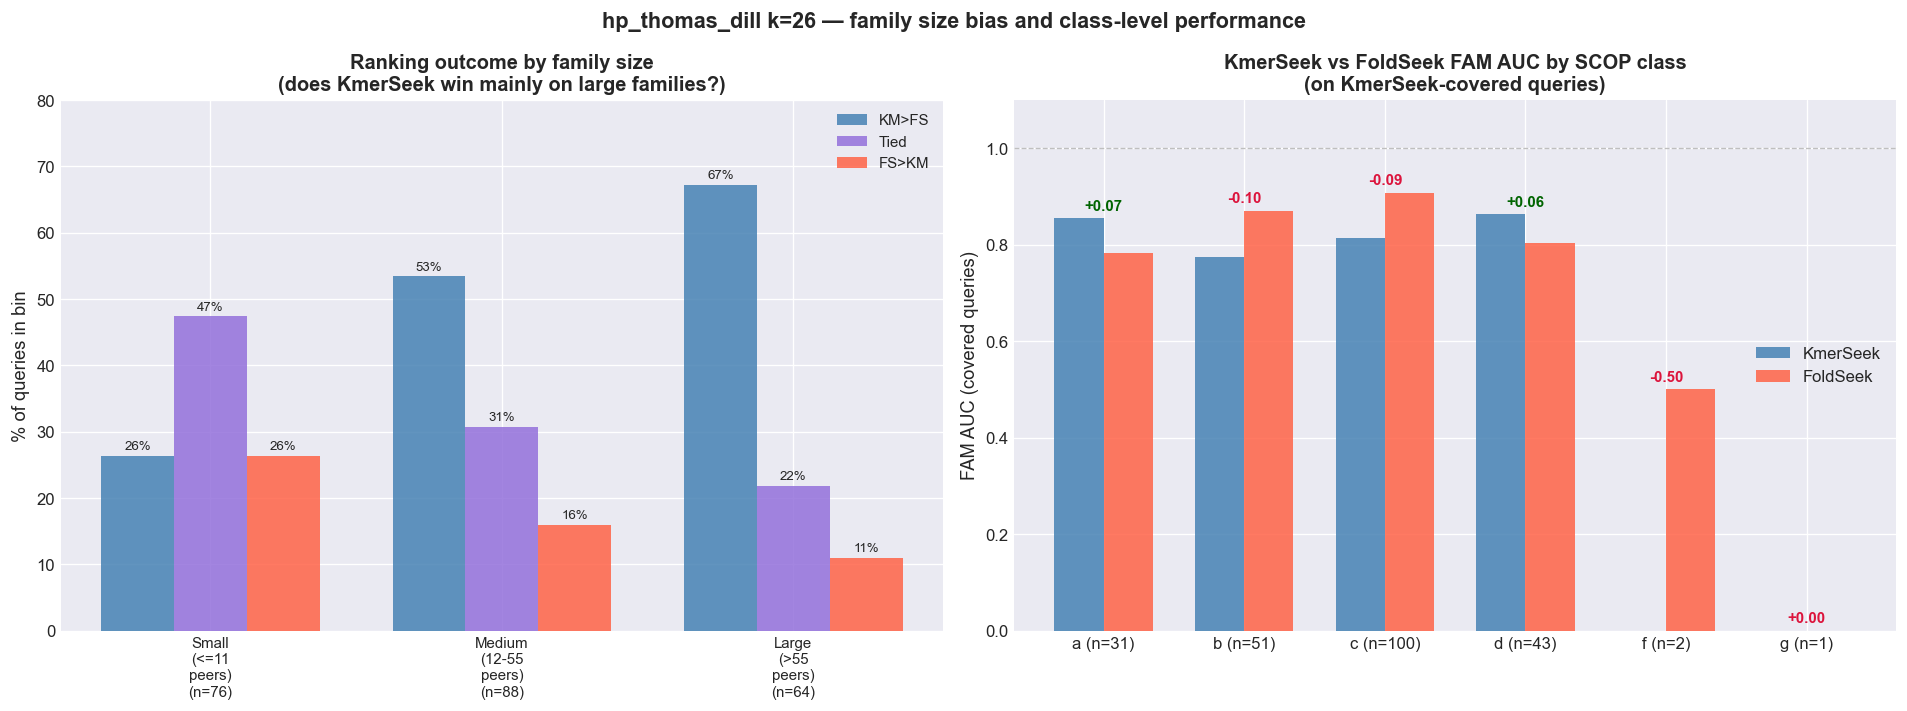

In [36]:
# Figure: Is KmerSeek winning on "easy" large families?
# And does KmerSeek do best at class c?

# -- Annotate per_q with family peer count and SCOP class --
per_q_ann = (
    per_q
    .join(scop_peers.select(['NAME','fam_peers']), on='NAME', how='left')
    .join(foldseek.select(['NAME','SCOP']).unique()
          .with_columns(pl.col('SCOP').str.slice(0,1).alias('cls')),
          on='NAME', how='left')
    .with_columns([
        pl.when(pl.col('km_fam') > pl.col('fs_fam')).then(pl.lit('KM>FS'))
          .when(pl.col('fs_fam') > pl.col('km_fam')).then(pl.lit('FS>KM'))
          .otherwise(pl.lit('Tied'))
          .alias('outcome'),
    ])
)

# -- Family size bins --
peers = per_q_ann['fam_peers'].fill_null(0).to_numpy()
q33, q67 = np.percentile(peers, 33), np.percentile(peers, 67)
print(f'Family peer count tertile cutoffs: {q33:.0f}, {q67:.0f}')

per_q_ann = per_q_ann.with_columns(
    pl.when(pl.col('fam_peers') <= q33).then(pl.lit('Small\n(<={}peers)'.format(int(q33))))
      .when(pl.col('fam_peers') <= q67).then(pl.lit('Medium\n({}-{}peers)'.format(int(q33)+1, int(q67))))
      .otherwise(pl.lit('Large\n(>{}peers)'.format(int(q67))))
      .alias('fam_size_bin')
)
bin_order = ['Small\n(<={}peers)'.format(int(q33)),
             'Medium\n({}-{}peers)'.format(int(q33)+1, int(q67)),
             'Large\n(>{}peers)'.format(int(q67))]

OUTCOME_COLORS = {'KM>FS': 'steelblue', 'Tied': 'mediumpurple', 'FS>KM': 'tomato'}
OUTCOME_ORDER  = ['KM>FS', 'Tied', 'FS>KM']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Left: % outcome by family size bin ──────────────────────────────────────
ax = axes[0]
x = np.arange(len(bin_order))
w = 0.25
for i, outcome in enumerate(OUTCOME_ORDER):
    pcts = []
    for b in bin_order:
        sub = per_q_ann.filter(pl.col('fam_size_bin') == b)
        n = sub.height
        pct = 100 * sub.filter(pl.col('outcome') == outcome).height / n if n > 0 else 0
        pcts.append(pct)
    bars = ax.bar(x + (i-1)*w, pcts, w, color=OUTCOME_COLORS[outcome],
                  alpha=0.85, label=outcome)
    for bar, pct in zip(bars, pcts):
        if pct > 3:
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                    '{:.0f}%'.format(pct), ha='center', va='bottom', fontsize=8)

bin_ns = [per_q_ann.filter(pl.col('fam_size_bin')==b).height for b in bin_order]
ax.set_xticks(x)
ax.set_xticklabels([b.replace('peers','\npeers') + '\n(n={})'.format(n)
                    for b, n in zip(bin_order, bin_ns)], fontsize=9)
ax.set_ylabel('% of queries in bin', fontsize=11)
ax.set_title('Ranking outcome by family size\n(does KmerSeek win mainly on large families?)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.set_ylim(0, 80)

# ── Right: KmerSeek vs FoldSeek FAM AUC by SCOP class ───────────────────────
ax = axes[1]
scop_classes_present = sorted(per_q_ann['cls'].drop_nulls().unique().to_list())
km_auc_by_cls, fs_auc_by_cls = [], []

for cls in scop_classes_present:
    names_cls = set(per_q_ann.filter(pl.col('cls') == cls)['NAME'].to_list())
    km_sub = km_rocx_r.filter(pl.col('NAME').is_in(names_cls))
    fs_sub = foldseek.filter(pl.col('NAME').is_in(names_cls))
    _, _, km_a = sensitivity_stats(km_sub, 'FAM')
    _, _, fs_a = sensitivity_stats(fs_sub, 'FAM')
    km_auc_by_cls.append(km_a)
    fs_auc_by_cls.append(fs_a)
    n = len(names_cls)
    print('Class {:} (n={:3d}): KmerSeek={:.3f}  FoldSeek={:.3f}  lift={:+.3f}'.format(
        cls, n, km_a, fs_a, km_a - fs_a))

x = np.arange(len(scop_classes_present))
w = 0.35
ax.bar(x-w/2, km_auc_by_cls, w, color='steelblue', alpha=0.85, label='KmerSeek')
ax.bar(x+w/2, fs_auc_by_cls, w, color='tomato',    alpha=0.85, label='FoldSeek')
for xi, (km, fs) in enumerate(zip(km_auc_by_cls, fs_auc_by_cls)):
    lift = km - fs
    color = 'darkgreen' if lift > 0 else 'crimson'
    ax.text(xi, max(km, fs) + 0.01, '{:+.2f}'.format(lift),
            ha='center', va='bottom', fontsize=9, color=color, fontweight='bold')

ns_by_cls = [per_q_ann.filter(pl.col('cls')==c).height for c in scop_classes_present]
ax.set_xticks(x)
ax.set_xticklabels(['{} (n={})'.format(c, n) for c, n in zip(scop_classes_present, ns_by_cls)],
                   fontsize=10)
ax.set_ylabel('FAM AUC (covered queries)', fontsize=11)
ax.set_ylim(0, 1.1)
ax.set_title('KmerSeek vs FoldSeek FAM AUC by SCOP class\n(on KmerSeek-covered queries)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.axhline(1.0, color='grey', lw=0.8, ls='--', alpha=0.5)

plt.suptitle('{} k={} — family size bias and class-level performance'.format(BEST_LABEL, BEST_K),
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('{}_family_size_and_class_auc.png'.format(FIG_PREFIX), dpi=150, bbox_inches='tight')
plt.show()


## 5. Sequence identity at HP k-mer loci

At what % amino-acid identity do KmerSeek's HP k-mer hits fire?
Window identity = fraction of identical residues over the matched HP k-mer window.


Pairs with seq data: 7,330
Family TPs        : n= 860  median=43.8%  <30%: 145  30-60%: 589  ≥60%: 126
Sfam TPs          : n=1513  median=43.3%  <30%: 289  30-60%:1021  ≥60%: 203
Fold TPs          : n=1570  median=42.4%  <30%: 345  30-60%:1022  ≥60%: 203
FPs (diff sfam)   : n=5817  median=12.1%


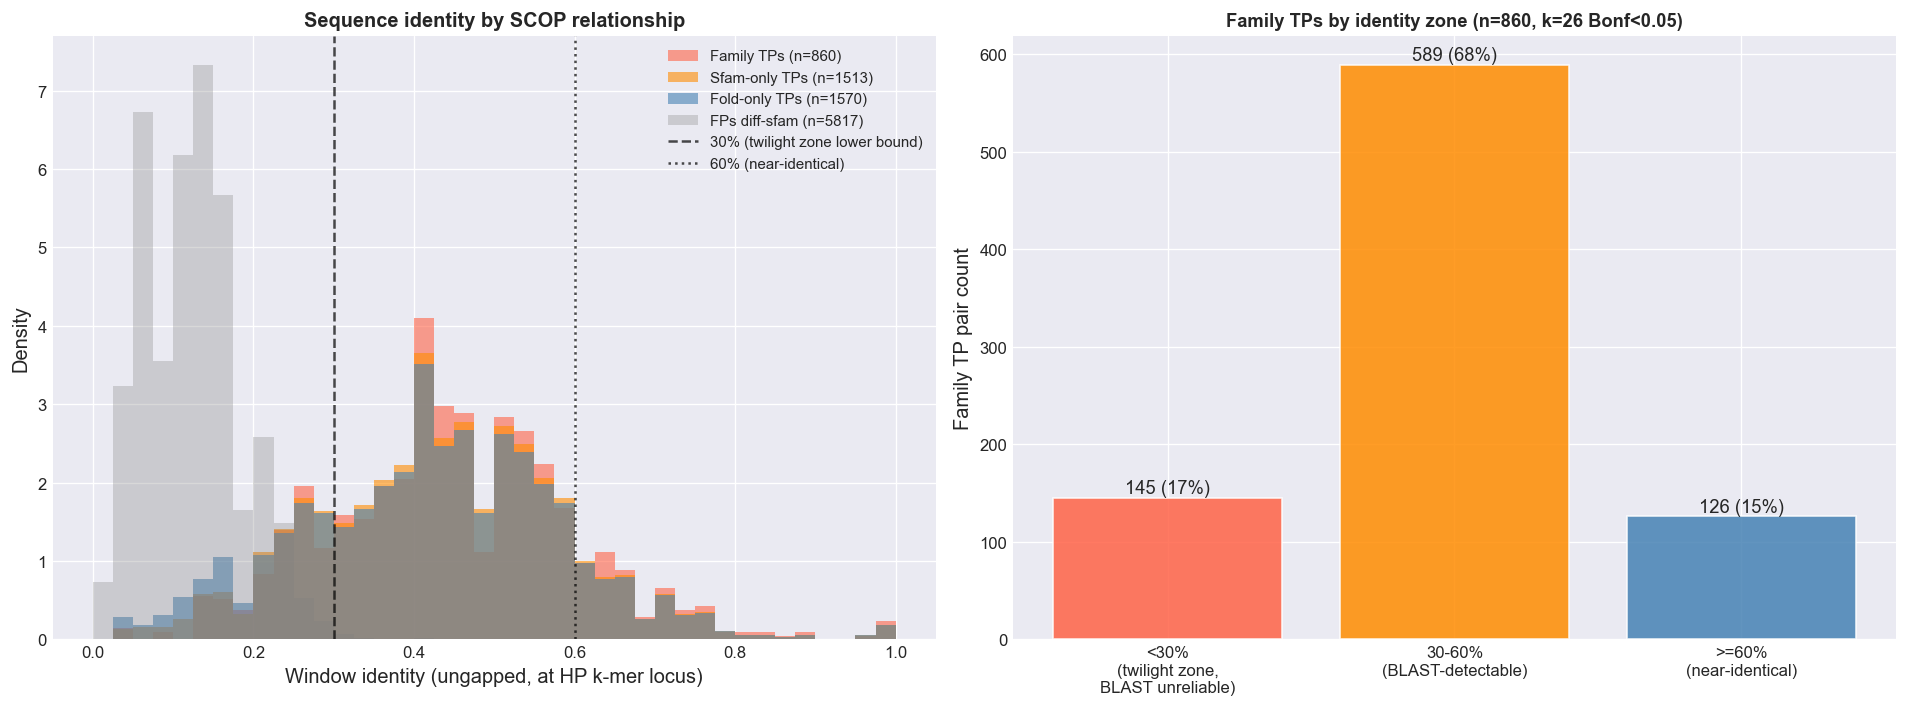

In [37]:
def window_identity(q, t):
    n = min(len(q), len(t))
    return sum(a==b for a,b in zip(q,t)) / n if n > 0 else float('nan')

seqid_rows = []
for row in ev_filt_seq.iter_rows(named=True):
    q = row.get('query_subseq','') or ''
    t = row.get('target_subseq','') or ''
    if not q or not t:
        continue
    seqid_rows.append({
        'same_family':      row['same_family'],
        'same_superfamily': row['same_superfamily'],
        'same_fold':        row['same_fold'],
        'window_identity':  window_identity(q, t),
    })
seqid_df = pl.DataFrame(seqid_rows)
print(f'Pairs with seq data: {len(seqid_df):,}')

fps = seqid_df.filter((pl.col('same_family')==False) & (pl.col('same_superfamily')==False))['window_identity'].drop_nulls()
for col, label in [('same_family','Family TPs'),('same_superfamily','Sfam TPs'),('same_fold','Fold TPs')]:
    s = seqid_df.filter(pl.col(col)==True)['window_identity'].drop_nulls()
    print('{:<18}: n={:4d}  median={:.1%}  <30%:{:4d}  30-60%:{:4d}  ≥60%:{:4d}'.format(
        label, len(s), s.median(), (s<0.30).sum(), ((s>=0.30)&(s<0.60)).sum(), (s>=0.60).sum()))
print('{:<18}: n={:4d}  median={:.1%}'.format('FPs (diff sfam)', len(fps), fps.median()))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
BINS = np.linspace(0, 1, 41)
ax = axes[0]
specs = [('same_family','Family TPs','tomato'),('same_superfamily','Sfam-only TPs','darkorange'),('same_fold','Fold-only TPs','steelblue')]
for col, lbl, color in specs:
    vals = seqid_df.filter(pl.col(col)==True)['window_identity'].drop_nulls().to_numpy()
    if len(vals): ax.hist(vals, bins=BINS, density=True, alpha=0.6, color=color, label='{} (n={})'.format(lbl,len(vals)))
ax.hist(fps.to_numpy(), bins=BINS, density=True, alpha=0.3, color='grey', label='FPs diff-sfam (n={})'.format(len(fps)))
ax.axvline(0.30, color='k', ls='--', lw=1.5, alpha=0.7, label='30% (twilight zone lower bound)')
ax.axvline(0.60, color='k', ls=':',  lw=1.5, alpha=0.7, label='60% (near-identical)')
ax.set_xlabel('Window identity (ungapped, at HP k-mer locus)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Sequence identity by SCOP relationship', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)

ax = axes[1]
fam_ids = seqid_df.filter(pl.col('same_family')==True)['window_identity'].drop_nulls().to_numpy()
zones   = ['<30%\n(twilight zone,\nBLAST unreliable)', '30-60%\n(BLAST-detectable)', '>=60%\n(near-identical)']
counts  = [(fam_ids<0.30).sum(), ((fam_ids>=0.30)&(fam_ids<0.60)).sum(), (fam_ids>=0.60).sum()]
bars = ax.bar(zones, counts, color=['tomato','darkorange','steelblue'], alpha=0.85, edgecolor='white')
for bar, n in zip(bars, counts):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            '{} ({:.0f}%)'.format(n, 100*n/len(fam_ids)), ha='center', va='bottom', fontsize=11)
ax.set_ylabel('Family TP pair count', fontsize=12)
ax.set_title('Family TPs by identity zone (n={}, k={} Bonf<{})'.format(len(fam_ids), BEST_K, BONF_THRESHOLD),
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('{}_sequence_identity.png'.format(FIG_PREFIX), dpi=150, bbox_inches='tight')
plt.show()


## 6. FoldSeek failure mode on KmerSeek-winning queries

For the queries where KmerSeek FAM > FoldSeek FAM: does FoldSeek fail at superfamily level too
(cross-fold FP), or only at family level (within-superfamily confusion)?


On KM-winning queries (n=110):
  FoldSeek FAM  AUC: 0.7931
  FoldSeek SFAM AUC: 0.6680
  KmerSeek FAM  AUC: 0.9909
  FoldSeek FAM=1.0 (perfect):  0
  FoldSeek FAM partial:        110
  FoldSeek FAM=0 (no TP):      0


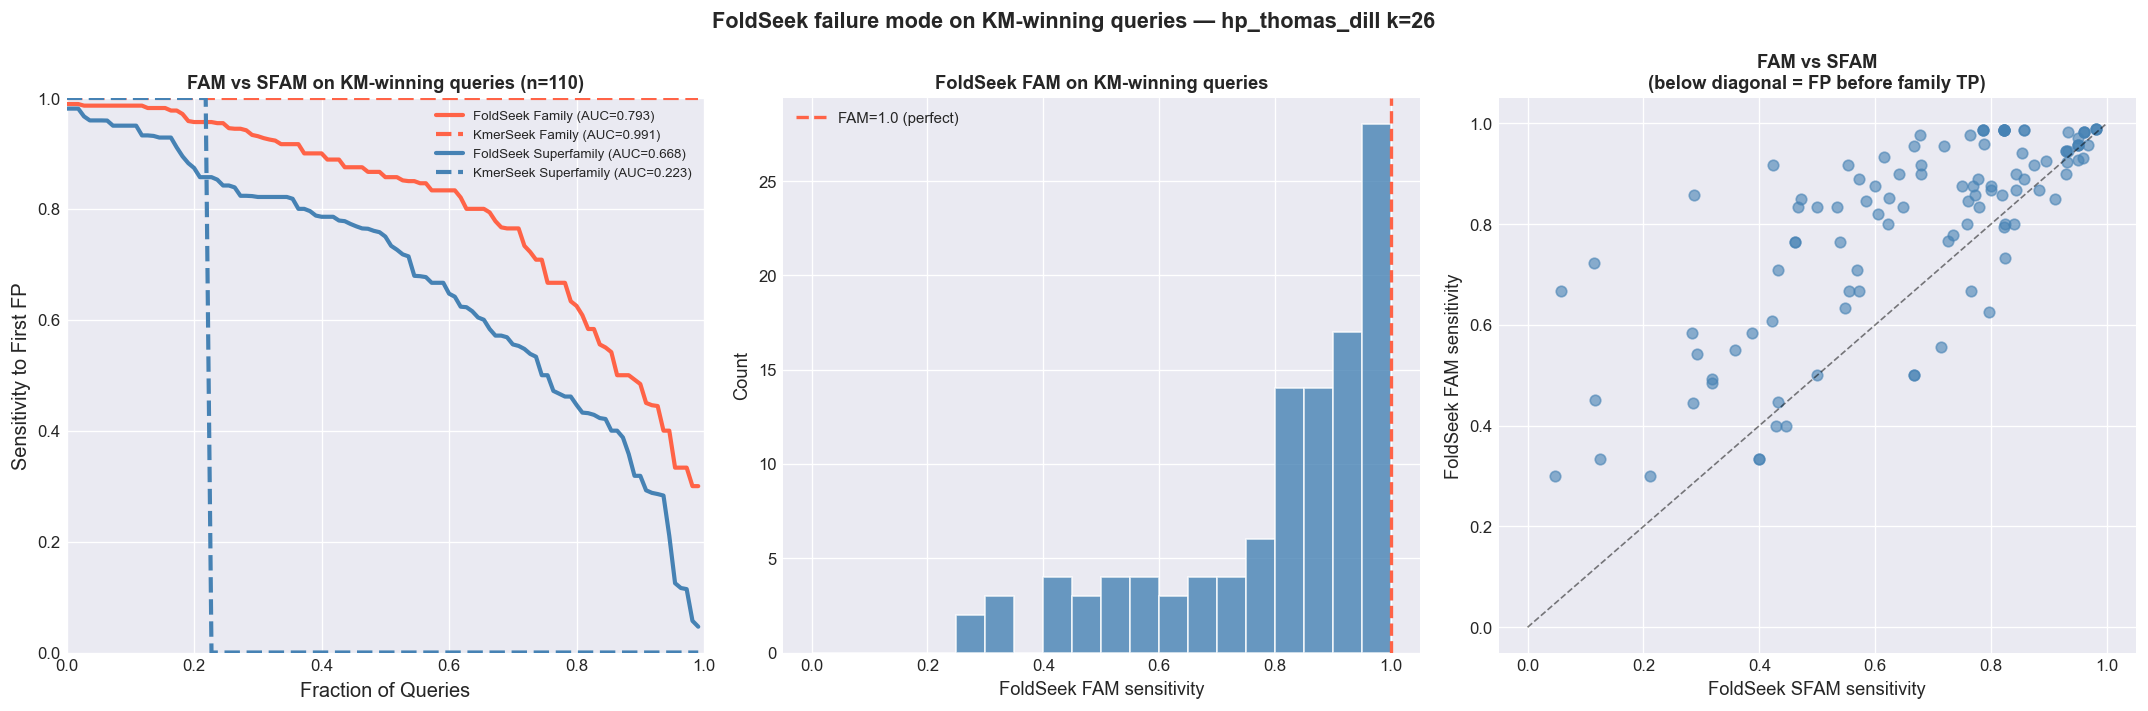

In [38]:
fs_km_wins = foldseek.filter(pl.col('NAME').is_in(km_beats_names))
km_km_wins = km_rocx_r.filter(pl.col('NAME').is_in(km_beats_names))

_, _, fs_fam_w  = sensitivity_stats(fs_km_wins, 'FAM')
_, _, fs_sfam_w = sensitivity_stats(fs_km_wins, 'SFAM')
_, _, km_fam_w  = sensitivity_stats(km_km_wins, 'FAM')

print('On KM-winning queries (n={:,}):'.format(len(km_beats_names)))
print('  FoldSeek FAM  AUC: {:.4f}'.format(fs_fam_w))
print('  FoldSeek SFAM AUC: {:.4f}'.format(fs_sfam_w))
print('  KmerSeek FAM  AUC: {:.4f}'.format(km_fam_w))

wins_merged = (fs_km_wins.select(['NAME','FAM','SFAM'])
               .join(km_km_wins.select(['NAME','FAM']).rename({'FAM':'km_fam'}), on='NAME', how='left'))
perfect_fs   = wins_merged.filter(pl.col('FAM') == 1.0)
imperfect_fs = wins_merged.filter(pl.col('FAM') <  1.0)
no_tp_fs     = wins_merged.filter(pl.col('FAM') == 0.0)

print('  FoldSeek FAM=1.0 (perfect):  {:,}'.format(len(perfect_fs)))
print('  FoldSeek FAM partial:        {:,}'.format(len(imperfect_fs)-len(no_tp_fs)))
print('  FoldSeek FAM=0 (no TP):      {:,}'.format(len(no_tp_fs)))

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
ax = axes[0]
for lc, ll, color in [('FAM','Family','tomato'),('SFAM','Superfamily','steelblue')]:
    fr, se, auc = sensitivity_stats(fs_km_wins, lc)
    ax.plot(fr, se, '-', color=color, lw=2.5, label='FoldSeek {} (AUC={:.3f})'.format(ll, auc))
    fr, se, auc = sensitivity_stats(km_km_wins, lc)
    ax.plot(fr, se, '--', color=color, lw=2.5, label='KmerSeek {} (AUC={:.3f})'.format(ll, auc))
ax.set_xlabel('Fraction of Queries', fontsize=12); ax.set_ylabel('Sensitivity to First FP', fontsize=12)
ax.set_title('FAM vs SFAM on KM-winning queries (n={:,})'.format(len(km_beats_names)), fontsize=11, fontweight='bold')
ax.legend(fontsize=8); ax.set_xlim(0,1); ax.set_ylim(0,1)

ax = axes[1]
ax.hist(fs_km_wins['FAM'].to_numpy(), bins=np.linspace(0,1,21), color='steelblue', alpha=0.8, edgecolor='white')
ax.axvline(1.0, color='tomato', ls='--', lw=2, label='FAM=1.0 (perfect)')
ax.set_xlabel('FoldSeek FAM sensitivity', fontsize=11); ax.set_ylabel('Count', fontsize=11)
ax.set_title('FoldSeek FAM on KM-winning queries', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)

ax = axes[2]
ax.scatter(fs_km_wins['SFAM'].to_numpy(), fs_km_wins['FAM'].to_numpy(),
           alpha=0.6, s=40, color='steelblue')
ax.plot([0,1],[0,1],'k--',lw=1,alpha=0.5)
ax.set_xlabel('FoldSeek SFAM sensitivity', fontsize=11); ax.set_ylabel('FoldSeek FAM sensitivity', fontsize=11)
ax.set_title('FAM vs SFAM\n(below diagonal = FP before family TP)', fontsize=11, fontweight='bold')
ax.set_xlim(-0.05,1.05); ax.set_ylim(-0.05,1.05)
plt.suptitle('FoldSeek failure mode on KM-winning queries — {} k={}'.format(BEST_LABEL, BEST_K),
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('{}_fs_failure_mode.png'.format(FIG_PREFIX), dpi=150, bbox_inches='tight')
plt.show()


## 7. Protein disorder: KmerSeek-winning vs tied queries

Do KmerSeek wins occur preferentially in disordered regions?
Uses metapredict to compute per-residue disorder scores.


Parsing FASTA...
  15,177 sequences loaded
Computing disorder for 228 covered queries...
  Done: 228

Full-protein disorder:
  KM>FS  n=110  median=0.114
  Tied   n=77  median=0.095
  FS>KM  n=41  median=0.069
  KM>FS vs Tied  p=0.032
  KM>FS vs FS>KM p=0.000
  Tied  vs FS>KM p=0.029

Overlap-window disorder:
  KM>FS  median=0.074  (n=110)
  Tied   median=0.061  (n=77)
  FS>KM  median=0.053  (n=41)
  KM>FS vs Tied overlap p=0.185

KEY FINDING: HP k-mer loci median disorder = 0.068
  -> KmerSeek fires in ordered (low-disorder) hydrophobic core regions


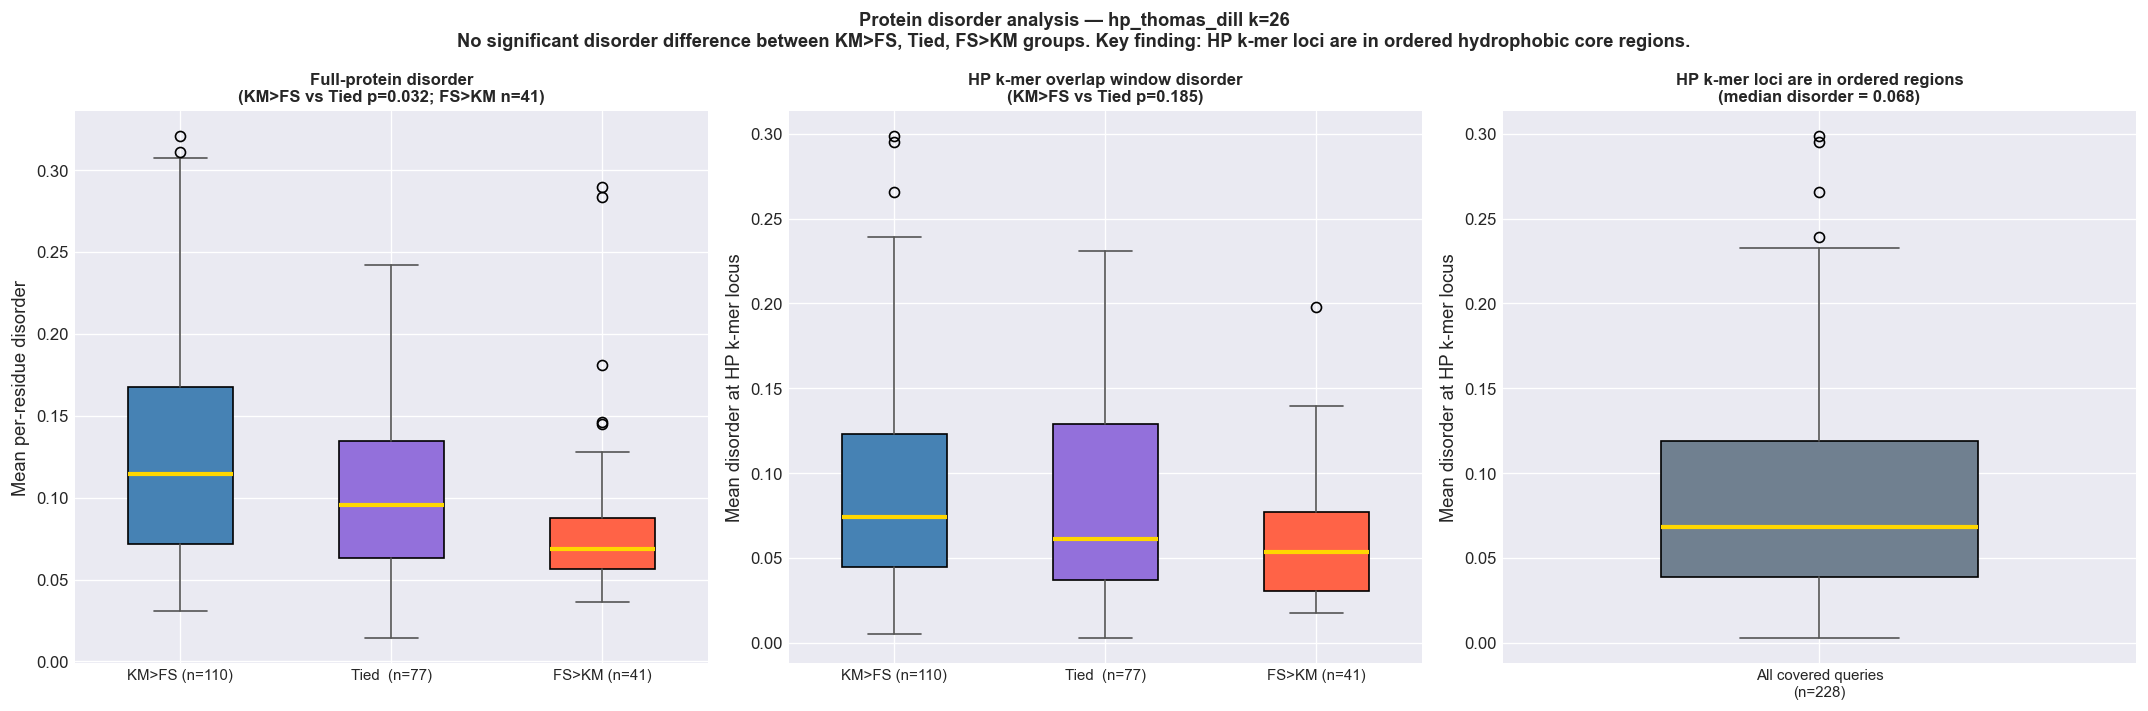

In [39]:
import metapredict as meta
_VALID_AA = set('ACDEFGHIKLMNPQRSTVWY')

def clean_seq(seq):
    return ''.join(aa if aa in _VALID_AA else 'G' for aa in seq.upper())

def parse_fasta(path):
    seqs = {}; cur_id = None; buf = []
    with open(path) as fh:
        for line in fh:
            line = line.rstrip()
            if line.startswith('>'):
                if cur_id: seqs[cur_id] = ''.join(buf)
                cur_id = line[1:].split()[0]; buf = []
            else:
                buf.append(line)
    if cur_id: seqs[cur_id] = ''.join(buf)
    return seqs

print('Parsing FASTA...')
all_seqs = parse_fasta(FASTA_PATH)
print(f'  {len(all_seqs):,} sequences loaded')

# Three groups: KM>FS, Tied, FS>KM (all 174 covered queries)
disorder_full = {}
print('Computing disorder for {:,} covered queries...'.format(len(covered)))
for qid in covered:
    raw = all_seqs.get(qid)
    if not raw: continue
    seq = clean_seq(raw)
    scores = meta.predict_disorder(seq)
    disorder_full[qid] = float(np.mean(scores))

print('  Done: {:,}'.format(len(disorder_full)))

wins_full  = [disorder_full[q] for q in km_beats_names if q in disorder_full]
tied_full  = [disorder_full[q] for q in tied_names     if q in disorder_full]
fs_full    = [disorder_full[q] for q in fs_beats_names  if q in disorder_full]

from scipy.stats import mannwhitneyu
_, p_wt = mannwhitneyu(wins_full, tied_full,  alternative='two-sided')
_, p_wf = mannwhitneyu(wins_full, fs_full,    alternative='two-sided')
_, p_tf = mannwhitneyu(tied_full, fs_full,    alternative='two-sided')
print()
print('Full-protein disorder:')
print('  KM>FS  n={:2d}  median={:.3f}'.format(len(wins_full), np.median(wins_full)))
print('  Tied   n={:2d}  median={:.3f}'.format(len(tied_full), np.median(tied_full)))
print('  FS>KM  n={:2d}  median={:.3f}'.format(len(fs_full),   np.median(fs_full)))
print('  KM>FS vs Tied  p={:.3f}'.format(p_wt))
print('  KM>FS vs FS>KM p={:.3f}'.format(p_wf))
print('  Tied  vs FS>KM p={:.3f}'.format(p_tf))

# Also compute disorder at HP k-mer overlap window
disorder_overlap = {}
for qid in covered:
    raw = all_seqs.get(qid)
    if not raw: continue
    seq = clean_seq(raw)
    scores = meta.predict_disorder(seq)
    q_hits = ev_filt_seq.filter(pl.col('query_domain') == qid).sort('poisson_pvalue')
    if q_hits.height > 0:
        row = q_hits.row(0, named=True)
        qs = max(0, row.get('query_start', 0) or 0)
        qe = min(len(scores), row.get('query_end', len(seq)) or len(seq))
        if qs < qe:
            disorder_overlap[qid] = float(np.mean(scores[qs:qe]))

wins_ov = [disorder_overlap[q] for q in km_beats_names if q in disorder_overlap]
tied_ov = [disorder_overlap[q] for q in tied_names     if q in disorder_overlap]
fs_ov   = [disorder_overlap[q] for q in fs_beats_names  if q in disorder_overlap]
_, p_ov_wt = mannwhitneyu(wins_ov, tied_ov, alternative='two-sided')

print()
print('Overlap-window disorder:')
print('  KM>FS  median={:.3f}  (n={})'.format(np.median(wins_ov), len(wins_ov)))
print('  Tied   median={:.3f}  (n={})'.format(np.median(tied_ov), len(tied_ov)))
print('  FS>KM  median={:.3f}  (n={})'.format(np.median(fs_ov),   len(fs_ov)))
print('  KM>FS vs Tied overlap p={:.3f}'.format(p_ov_wt))
print()
print('KEY FINDING: HP k-mer loci median disorder = {:.3f}'.format(np.median(wins_ov + tied_ov + fs_ov)))
print('  -> KmerSeek fires in ordered (low-disorder) hydrophobic core regions')

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
COLORS = {'KM>FS': 'steelblue', 'Tied': 'mediumpurple', 'FS>KM': 'tomato'}

for ax, (data_sets, title, ylabel) in zip(axes, [
    ([(wins_full,  'KM>FS (n={})'.format(len(wins_full)),  'steelblue'),
      (tied_full,  'Tied  (n={})'.format(len(tied_full)),  'mediumpurple'),
      (fs_full,    'FS>KM (n={})'.format(len(fs_full)),    'tomato')],
     'Full-protein disorder\n(KM>FS vs Tied p={:.3f}; FS>KM n={})'.format(p_wt, len(fs_full)),
     'Mean per-residue disorder'),
    ([(wins_ov, 'KM>FS (n={})'.format(len(wins_ov)), 'steelblue'),
      (tied_ov, 'Tied  (n={})'.format(len(tied_ov)), 'mediumpurple'),
      (fs_ov,   'FS>KM (n={})'.format(len(fs_ov)),   'tomato')],
     'HP k-mer overlap window disorder\n(KM>FS vs Tied p={:.3f})'.format(p_ov_wt),
     'Mean disorder at HP k-mer locus'),
    ([(wins_ov + tied_ov + fs_ov, 'All covered queries\n(n={})'.format(len(wins_ov+tied_ov+fs_ov)), 'slategray')],
     'HP k-mer loci are in ordered regions\n(median disorder = {:.3f})'.format(
         np.median(wins_ov + tied_ov + fs_ov)),
     'Mean disorder at HP k-mer locus'),
]):
    groups = [d for d, _, _ in data_sets]
    labels = [l for _, l, _ in data_sets]
    colors_list = [c for _, _, c in data_sets]
    bp = ax.boxplot(groups, patch_artist=True, widths=0.5, medianprops=dict(color='gold', lw=2.5))
    for box, c in zip(bp['boxes'], colors_list):
        box.set_facecolor(c)
    for patch_list in [bp['whiskers'], bp['caps']]:
        for p_ in patch_list: p_.set_color('#555')
    ax.set_xticks(list(range(1, len(groups)+1)))
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=10, fontweight='bold')

plt.suptitle('Protein disorder analysis — {} k={}\n'.format(BEST_LABEL, BEST_K) +
    'No significant disorder difference between KM>FS, Tied, FS>KM groups. ' +
    'Key finding: HP k-mer loci are in ordered hydrophobic core regions.',
    fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('{}_disorder.png'.format(FIG_PREFIX), dpi=150, bbox_inches='tight')
plt.show()

## 8. Per-SCOPe Class: Disorder and Identity

Breakdown of protein disorder and HP k-mer window sequence identity by SCOPe structural class (a = all-alpha, b = all-beta, c = alpha+beta, d = alpha/beta, etc.).

Per-SCOPe class disorder (mean per-residue score):
Class Description                         n   Median     Min     Max
------------------------------------------------------------
a    All alpha proteins                 31    0.122   0.055   0.321
b    All beta proteins                  51    0.131   0.046   0.290
c    Alpha and beta proteins (a/b)     100    0.070   0.014   0.294
d    Alpha and beta proteins (a+b)      43    0.128   0.037   0.311
f    Membrane and cell surface prot      2    0.048   0.040   0.056
g    Small proteins                      1    0.242   0.242   0.242

Per-class per-outcome disorder medians:
Class Outcome       n   Median
a    KM>FS        21    0.124
a    Tied          6    0.126
a    FS>KM         4    0.073
b    KM>FS        19    0.155
b    Tied         21    0.135
b    FS>KM        11    0.078
c    KM>FS        44    0.080
c    Tied         38    0.065
c    FS>KM        18    0.064
d    KM>FS        26    0.127
d    Tied         11    0.133
d    FS>K

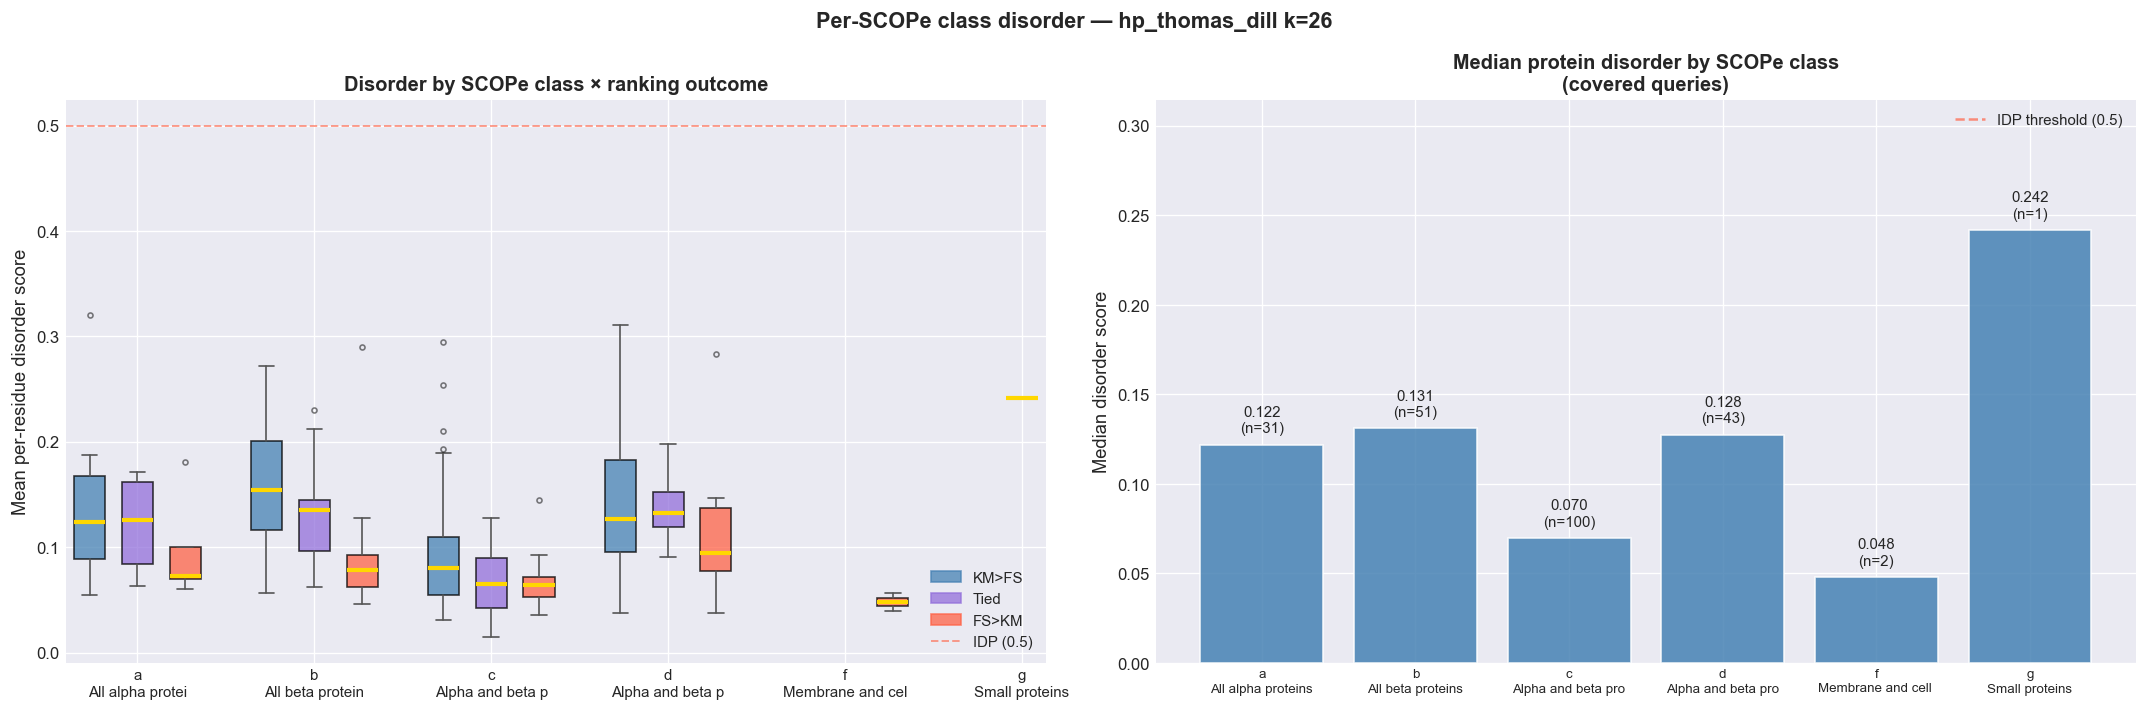

In [40]:
# ── Per-SCOPe class: disorder ────────────────────────────────────────────────
disorder_cls_df = (
    pl.DataFrame({'NAME': list(disorder_full.keys()), 'disorder': list(disorder_full.values())})
    .join(per_q_ann.select(['NAME', 'cls', 'outcome']), on='NAME', how='left')
    .with_columns(pl.col('cls').fill_null('?'))
)

scop_classes = sorted(disorder_cls_df['cls'].drop_nulls().unique().to_list())
OUTCOME_ORDER  = ['KM>FS', 'Tied', 'FS>KM']
OUTCOME_COLORS = {'KM>FS': 'steelblue', 'Tied': 'mediumpurple', 'FS>KM': 'tomato'}

# ── Summary table ────────────────────────────────────────────────────────────
print('Per-SCOPe class disorder (mean per-residue score):')
print(f'{"Class":<4} {"Description":<32} {"n":>4} {"Median":>8} {"Min":>7} {"Max":>7}')
print('-' * 60)
for cls in scop_classes:
    vals = disorder_cls_df.filter(pl.col('cls') == cls)['disorder'].drop_nulls().to_numpy()
    desc = SCOPE_CLASS_DESCRIPTIONS.get(cls, cls)[:30]
    print(f'{cls:<4} {desc:<32} {len(vals):>4} {np.median(vals):>8.3f} {vals.min():>7.3f} {vals.max():>7.3f}')

print()
print('Per-class per-outcome disorder medians:')
print(f'{"Class":<4} {"Outcome":<10} {"n":>4} {"Median":>8}')
for cls in scop_classes:
    for outcome in OUTCOME_ORDER:
        sub = disorder_cls_df.filter(
            (pl.col('cls') == cls) & (pl.col('outcome') == outcome)
        )['disorder'].drop_nulls().to_numpy()
        if len(sub) > 0:
            print(f'{cls:<4} {outcome:<10} {len(sub):>4} {np.median(sub):>8.3f}')

# ── Figure ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Left: grouped box plots per class × outcome
ax = axes[0]
positions, data_list, colors_list = [], [], []
tick_positions, tick_labels = [], []
pos = 0
for cls in scop_classes:
    desc = SCOPE_CLASS_DESCRIPTIONS.get(cls, cls)[:16]
    center = pos + (len(OUTCOME_ORDER) - 1) / 2
    tick_positions.append(center)
    tick_labels.append(f'{cls}\n{desc}')
    for outcome in OUTCOME_ORDER:
        sub = disorder_cls_df.filter(
            (pl.col('cls') == cls) & (pl.col('outcome') == outcome)
        )['disorder'].drop_nulls().to_numpy()
        if len(sub) > 0:
            positions.append(pos)
            data_list.append(sub)
            colors_list.append(OUTCOME_COLORS[outcome])
        pos += 1
    pos += 0.7  # gap between classes

if data_list:
    bp = ax.boxplot(data_list, positions=positions, patch_artist=True, widths=0.65,
                    showfliers=True, flierprops=dict(markersize=3, alpha=0.5),
                    medianprops=dict(color='gold', lw=2.5))
    for box, c in zip(bp['boxes'], colors_list):
        box.set_facecolor(c); box.set_alpha(0.75)
    for p_ in bp['whiskers'] + bp['caps']:
        p_.set_color('#555')

ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, fontsize=9)
ax.set_ylabel('Mean per-residue disorder score', fontsize=11)
ax.set_title('Disorder by SCOPe class × ranking outcome', fontsize=12, fontweight='bold')
ax.axhline(0.5, color='tomato', ls='--', lw=1.2, alpha=0.6, label='IDP threshold (0.5)')
patches = [mpatches.Patch(color=OUTCOME_COLORS[o], label=o, alpha=0.75) for o in OUTCOME_ORDER]
ax.legend(handles=patches + [plt.Line2D([0],[0],color='tomato',ls='--',lw=1.2,alpha=0.6,label='IDP (0.5)')],
          fontsize=9)

# Right: median disorder per class (all covered queries)
ax = axes[1]
medians, ns = [], []
for cls in scop_classes:
    vals = disorder_cls_df.filter(pl.col('cls') == cls)['disorder'].drop_nulls().to_numpy()
    medians.append(np.median(vals) if len(vals) > 0 else np.nan)
    ns.append(len(vals))

bars = ax.bar(range(len(scop_classes)), medians, color='steelblue', alpha=0.85, edgecolor='white')
for bar, n, med in zip(bars, ns, medians):
    if not np.isnan(med):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{med:.3f}\n(n={n})', ha='center', va='bottom', fontsize=9)
ax.set_xticks(range(len(scop_classes)))
ax.set_xticklabels([f'{c}\n{SCOPE_CLASS_DESCRIPTIONS.get(c, c)[:18]}' for c in scop_classes], fontsize=8)
ax.set_ylabel('Median disorder score', fontsize=11)
ax.set_ylim(0, max(m for m in medians if not np.isnan(m)) * 1.30)
ax.set_title('Median protein disorder by SCOPe class\n(covered queries)', fontsize=12, fontweight='bold')
ax.axhline(0.5, color='tomato', ls='--', lw=1.5, alpha=0.7, label='IDP threshold (0.5)')
ax.legend(fontsize=9)

plt.suptitle(f'Per-SCOPe class disorder — {BEST_LABEL} k={BEST_K}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIG_PREFIX}_per_class_disorder.png', dpi=150, bbox_inches='tight')
plt.show()

Pairs with seq data + class: 7,330

Per-SCOPe class identity — family TPs:
Class Description                        n   Median    <30%   30-60%    >=60%
--------------------------------------------------------------------
d    Alpha and beta proteins (a+b     855    43.8%     17%      69%      15%
g    Small proteins                     5    43.3%     20%      60%      20%

Per-SCOPe class identity — all relationship levels:
  Family TPs    : n= 860  median=43.8%
  Sfam TPs      : n=1513  median=43.3%
  FPs           : n=5817  median=12.1%


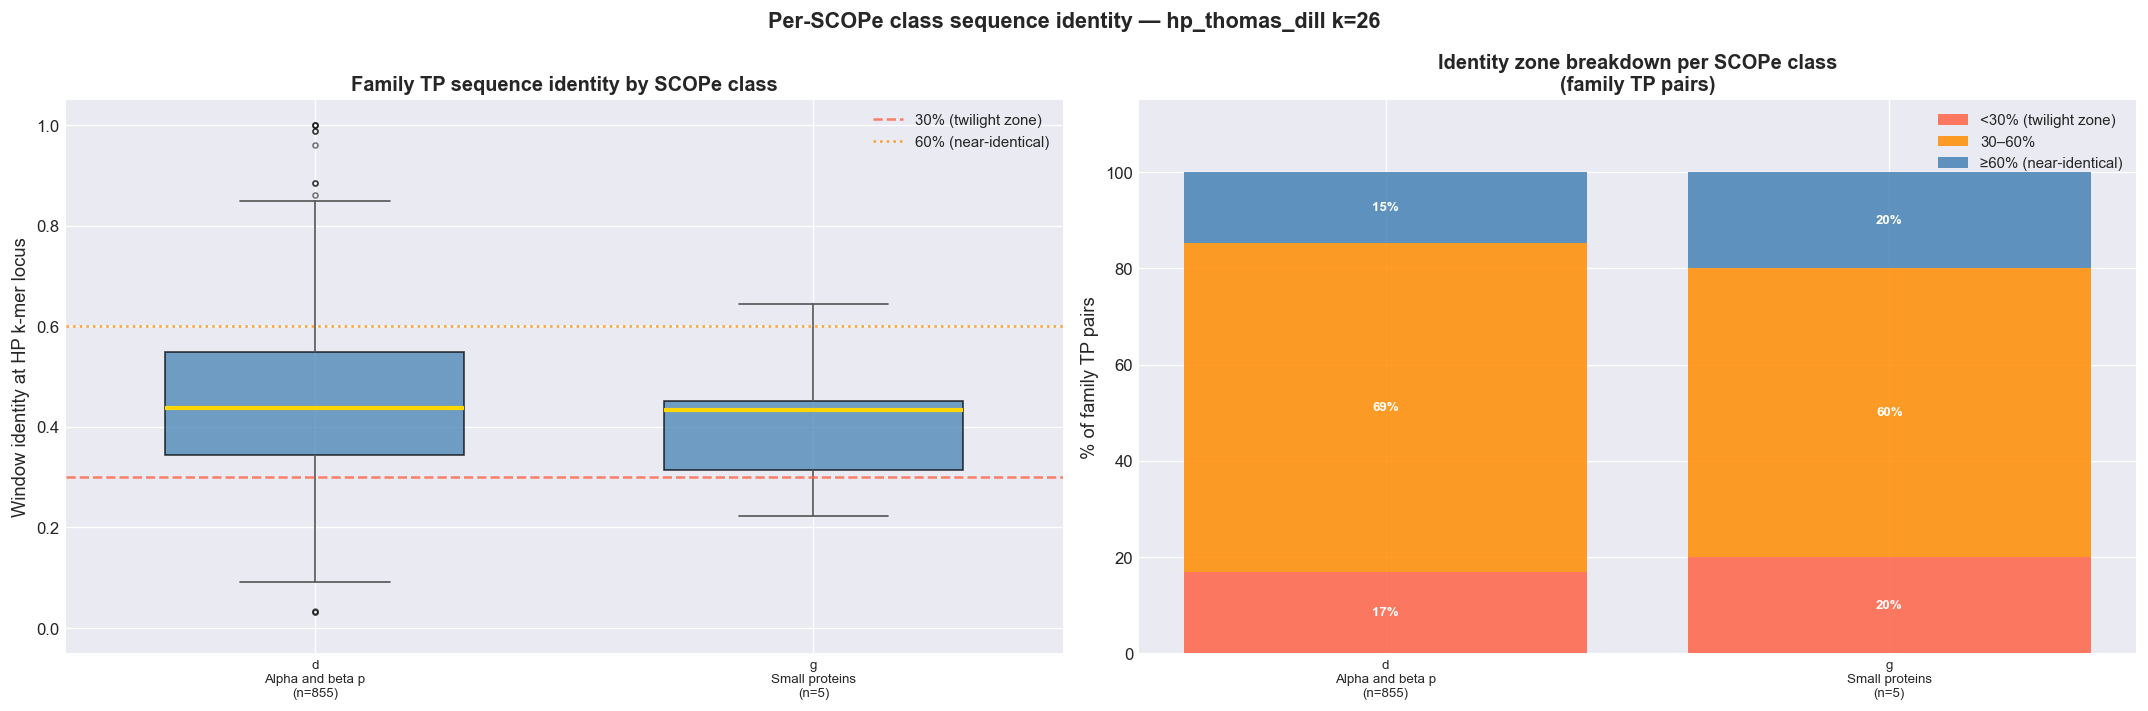

In [41]:
# ── Per-SCOPe class: sequence identity ───────────────────────────────────────
# Rebuild with SCOP class; first char of query_domain is the SCOPe class letter
seqid_cls_rows = []
for row in ev_filt_seq.iter_rows(named=True):
    q = row.get('query_subseq', '') or ''
    t = row.get('target_subseq', '') or ''
    if not q or not t:
        continue
    qd  = row.get('query_domain', '') or ''
    # q_scop_class if present, else infer from domain name first character
    cls = (row.get('q_scop_class') or qd[:1] or '?')[:1].lower()
    seqid_cls_rows.append({
        'same_family':      row['same_family'],
        'same_superfamily': row['same_superfamily'],
        'same_fold':        row['same_fold'],
        'window_identity':  window_identity(q, t),
        'cls':              cls,
    })
seqid_cls_df = pl.DataFrame(seqid_cls_rows)
scop_classes_id = sorted(seqid_cls_df['cls'].drop_nulls().unique().to_list())
print(f'Pairs with seq data + class: {len(seqid_cls_df):,}')

# ── Summary table ────────────────────────────────────────────────────────────
print()
print('Per-SCOPe class identity — family TPs:')
print(f'{"Class":<4} {"Description":<30} {"n":>5} {"Median":>8}  {"<30%":>6}  {"30-60%":>7}  {">=60%":>7}')
print('-' * 68)
for cls in scop_classes_id:
    fam_tp = seqid_cls_df.filter(
        (pl.col('cls') == cls) & (pl.col('same_family') == True)
    )['window_identity'].drop_nulls().to_numpy()
    if len(fam_tp) == 0:
        continue
    n    = len(fam_tp)
    desc = SCOPE_CLASS_DESCRIPTIONS.get(cls, cls)[:28]
    print(f'{cls:<4} {desc:<30} {n:>5} {np.median(fam_tp):>8.1%}'
          f'  {100*(fam_tp<0.30).sum()/n:>5.0f}%'
          f'  {100*((fam_tp>=0.30)&(fam_tp<0.60)).sum()/n:>6.0f}%'
          f'  {100*(fam_tp>=0.60).sum()/n:>6.0f}%')

print()
print('Per-SCOPe class identity — all relationship levels:')
for rel, col in [('Family TPs','same_family'),('Sfam TPs','same_superfamily'),('FPs','same_family')]:
    if col == 'same_family' and rel == 'FPs':
        sub = seqid_cls_df.filter(
            (pl.col('same_family') == False) & (pl.col('same_superfamily') == False)
        )['window_identity'].drop_nulls().to_numpy()
    else:
        sub = seqid_cls_df.filter(pl.col(col) == True)['window_identity'].drop_nulls().to_numpy()
    print(f'  {rel:<14}: n={len(sub):4d}  median={np.median(sub):.1%}')

# ── Figure ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Left: box plots of window identity per class (family TPs)
ax = axes[0]
data_by_cls, labels_by_cls = [], []
for cls in scop_classes_id:
    fam_tp = seqid_cls_df.filter(
        (pl.col('cls') == cls) & (pl.col('same_family') == True)
    )['window_identity'].drop_nulls().to_numpy()
    if len(fam_tp) > 0:
        data_by_cls.append(fam_tp)
        labels_by_cls.append(
            f'{cls}\n{SCOPE_CLASS_DESCRIPTIONS.get(cls, cls)[:16]}\n(n={len(fam_tp)})'
        )

if data_by_cls:
    bp = ax.boxplot(data_by_cls, patch_artist=True, widths=0.6,
                    showfliers=True, flierprops=dict(markersize=3, alpha=0.5),
                    medianprops=dict(color='gold', lw=2.5))
    for box in bp['boxes']:
        box.set_facecolor('steelblue'); box.set_alpha(0.75)
    for p_ in bp['whiskers'] + bp['caps']:
        p_.set_color('#555')

ax.axhline(0.30, color='tomato',     ls='--', lw=1.5, alpha=0.8, label='30% (twilight zone)')
ax.axhline(0.60, color='darkorange', ls=':',  lw=1.5, alpha=0.8, label='60% (near-identical)')
ax.set_xticks(range(1, len(data_by_cls) + 1))
ax.set_xticklabels(labels_by_cls, fontsize=8)
ax.set_ylabel('Window identity at HP k-mer locus', fontsize=11)
ax.set_ylim(-0.05, 1.05)
ax.set_title('Family TP sequence identity by SCOPe class', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)

# Right: stacked bar — identity zones per class (family TPs)
ax = axes[1]
fracs_lt30, fracs_mid, fracs_gt60, ns_cls = [], [], [], []
for cls in scop_classes_id:
    fam_tp = seqid_cls_df.filter(
        (pl.col('cls') == cls) & (pl.col('same_family') == True)
    )['window_identity'].drop_nulls().to_numpy()
    n = len(fam_tp)
    ns_cls.append(n)
    if n == 0:
        fracs_lt30.append(0); fracs_mid.append(0); fracs_gt60.append(0)
    else:
        fracs_lt30.append(100 * (fam_tp < 0.30).sum() / n)
        fracs_mid.append(100 * ((fam_tp >= 0.30) & (fam_tp < 0.60)).sum() / n)
        fracs_gt60.append(100 * (fam_tp >= 0.60).sum() / n)

x = np.arange(len(scop_classes_id))
ax.bar(x, fracs_lt30, color='tomato',     alpha=0.85, label='<30% (twilight zone)')
ax.bar(x, fracs_mid,  bottom=fracs_lt30,  color='darkorange', alpha=0.85, label='30–60%')
ax.bar(x, fracs_gt60, bottom=[a + b for a, b in zip(fracs_lt30, fracs_mid)],
       color='steelblue', alpha=0.85, label='≥60% (near-identical)')

# Label each zone if wide enough
for xi, (lt30, mid, gt60) in enumerate(zip(fracs_lt30, fracs_mid, fracs_gt60)):
    for val, offset in [(lt30, lt30/2), (mid, lt30 + mid/2), (gt60, lt30 + mid + gt60/2)]:
        if val > 8:
            ax.text(xi, offset, f'{val:.0f}%', ha='center', va='center',
                    fontsize=8, color='white', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(
    [f'{c}\n{SCOPE_CLASS_DESCRIPTIONS.get(c, c)[:16]}\n(n={n})'
     for c, n in zip(scop_classes_id, ns_cls)],
    fontsize=8)
ax.set_ylabel('% of family TP pairs', fontsize=11)
ax.set_ylim(0, 115)
ax.set_title('Identity zone breakdown per SCOPe class\n(family TP pairs)', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)

plt.suptitle(f'Per-SCOPe class sequence identity — {BEST_LABEL} k={BEST_K}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIG_PREFIX}_per_class_identity.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Summary

In [42]:
print('=' * 70)
print('SUMMARY: {} k={} mechanism analysis'.format(BEST_LABEL, BEST_K))
print('=' * 70)
print('Covered queries (Bonf<{}):'.format(BONF_THRESHOLD))
print('  KmerSeek total (all 15,177 SCOPe-40):  {:,}'.format(n_km_total))
print('  In FoldSeek benchmark:                  {:,}'.format(len(covered)))
print()
print('Head-to-head (covered queries, n={:,}):'.format(len(covered)))
print('  KmerSeek FAM  AUC: {:.4f}'.format(km_fam))
print('  FoldSeek FAM  AUC: {:.4f}'.format(fsc_fam))
print()
print('Per-query ranking:')
print('  KM > FS: {:,}  |  FS > KM: {:,}  |  Tied: {:,}'.format(
    len(km_beats_names), len(fs_beats_names), len(tied_names)))
print()
print('Sequence identity of family TPs:')
fam_ids = seqid_df.filter(pl.col('same_family')==True)['window_identity'].drop_nulls().to_numpy()
print('  median={:.1%}  <30%: {:.0f}%  30-60%: {:.0f}%  >=60%: {:.0f}%'.format(
    np.median(fam_ids),
    100*(fam_ids<0.30).sum()/len(fam_ids),
    100*((fam_ids>=0.30)&(fam_ids<0.60)).sum()/len(fam_ids),
    100*(fam_ids>=0.60).sum()/len(fam_ids)))


SUMMARY: hp_thomas_dill k=26 mechanism analysis
Covered queries (Bonf<0.05):
  KmerSeek total (all 15,177 SCOPe-40):  683
  In FoldSeek benchmark:                  228

Head-to-head (covered queries, n=228):
  KmerSeek FAM  AUC: 0.8209
  FoldSeek FAM  AUC: 0.8728

Per-query ranking:
  KM > FS: 110  |  FS > KM: 41  |  Tied: 77

Sequence identity of family TPs:
  median=43.8%  <30%: 17%  30-60%: 68%  >=60%: 15%
